# Cryptocurrency Volatility Prediction using Machine Learning

## Introduction

Cryptocurrency markets are highly volatile and unpredictable.  
Volatility refers to the degree of variation in cryptocurrency prices over time.

Predicting volatility helps traders and investors understand risk and make better financial decisions.

In this project, a machine learning model is developed to predict cryptocurrency volatility using historical market data such as open, high, low, close prices, trading volume, and market capitalization.

In [12]:
# Import necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [14]:
# Load dataset

df = pd.read_csv('/content/dataset.csv.zip')

df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [ ]:
# dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [ ]:
# statistical summary

df.describe()

,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


## Dataset Description

The dataset contains historical daily cryptocurrency data.

Features included in the dataset:

- Open Price
- High Price
- Low Price
- Close Price
- Trading Volume
- Market Capitalization
- Date
- Cryptocurrency Name

This dataset helps analyze market behavior and price movements.

In [27]:
# remove unwanted column

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [26]:
df['date'] = pd.to_datetime(df['date'])

In [25]:
df.isnull().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [24]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_267/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [23]:
#feature enginnering
df['volatility'] = (df['high'] - df['low']) / df['close']

In [22]:
df['MA_7'] = df['close'].rolling(window=7).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()

In [21]:
df['liquidity'] = df['volume'] / df['marketCap']

In [20]:
df = df.dropna()

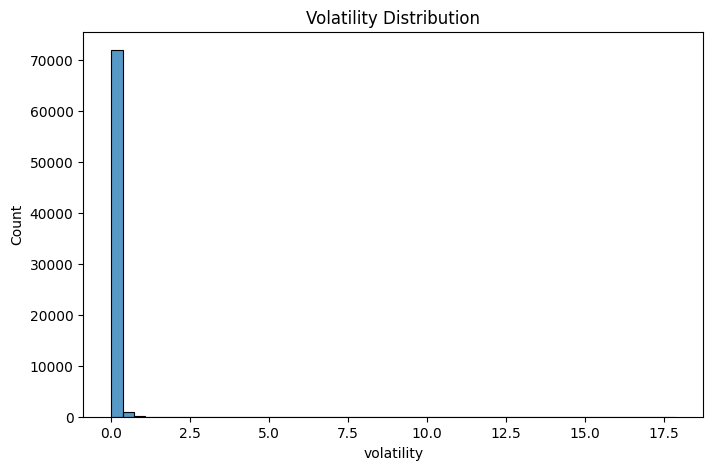

In [28]:
#EDA
plt.figure(figsize=(8,5))

sns.histplot(df['volatility'], bins=50)

plt.title("Volatility Distribution")

plt.show()

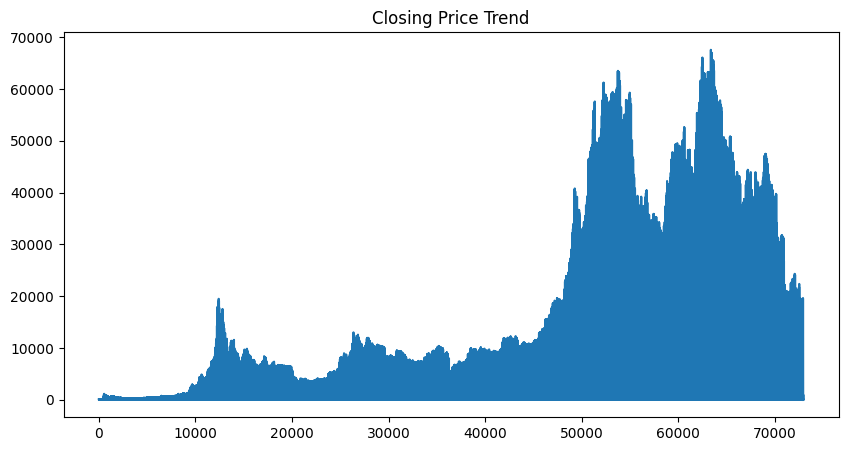

In [18]:
plt.figure(figsize=(10,5))

plt.plot(df['close'])

plt.title("Closing Price Trend")

plt.show()

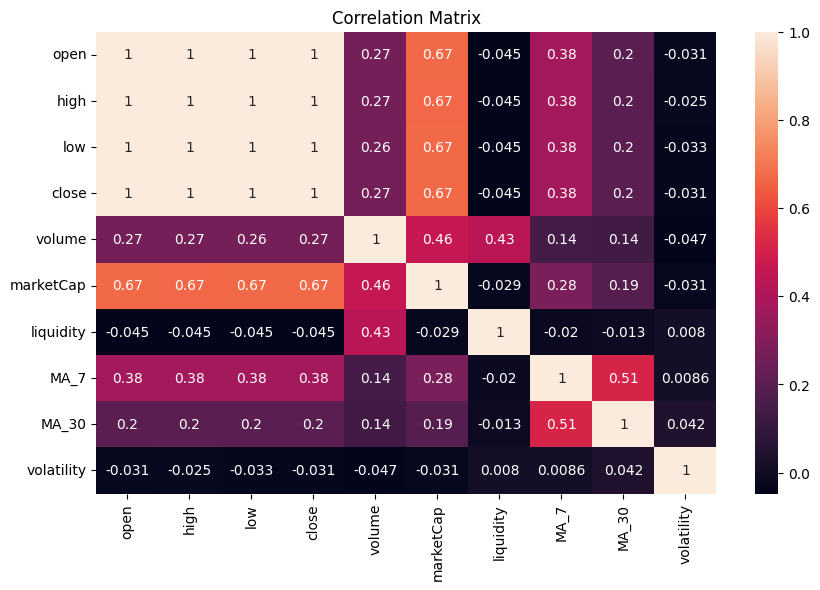

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Matrix")

plt.show()

### Insights from EDA

- Closing price shows significant variation over time.
- Volume and market capitalization influence volatility.
- High correlation exists between price-based features.

In [30]:
#Feature section
features = [
'open',
'high',
'low',
'close',
'volume',
'marketCap',
'MA_7',
'MA_30',
'liquidity'
]

X = df[features]

y = df['volatility']

In [38]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [39]:
import numpy as np

# Replace inf with NaN
X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_test = np.where(np.isinf(X_test), np.nan, X_test)

# Replace NaN with column mean
col_mean = np.nanmean(X_train, axis=0)

inds = np.where(np.isnan(X_train))
X_train[inds] = np.take(col_mean, inds[1])

inds = np.where(np.isnan(X_test))
X_test[inds] = np.take(col_mean, inds[1])

print("Infinite values handled")

Infinite values handled


In [40]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [41]:
model = RandomForestRegressor(
n_estimators=200,
random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [42]:
y_pred = model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.029822772028135328
RMSE: 0.15823059039124002
R2 Score: 0.20717865599325513


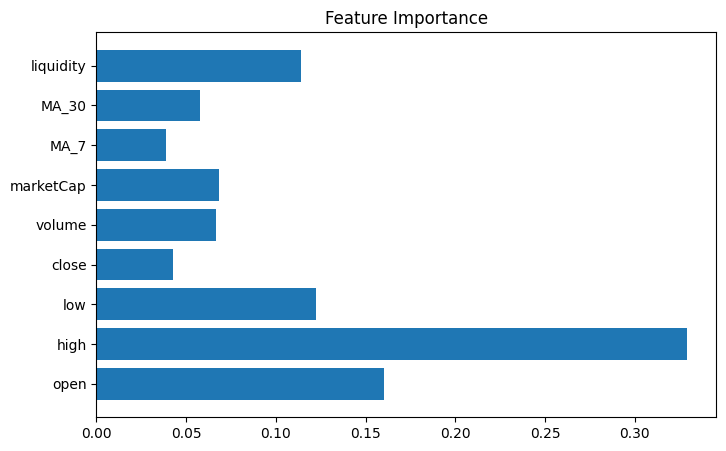

In [44]:
importance = model.feature_importances_

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

## Conclusion

In this project, a machine learning model was developed to predict cryptocurrency volatility using historical market data.

Feature engineering techniques such as moving averages and liquidity ratios were applied to capture market trends.

The Random Forest regression model was trained and evaluated using MAE, RMSE, and R² score.

The results demonstrate that machine learning can effectively analyze financial data and identify patterns in cryptocurrency volatility.